# Cricket Shot Feedback – Corrected Seq2Seq (Manual Tokenization)
**Encoder fixed, inference fixed, vocabulary unchanged**

In [3]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import re

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Load & Encoder Input

In [4]:

df = pd.read_csv("/content/drive/MyDrive/cricket_shot_feedback_dataset_FINAL.csv")

numeric_cols = [
    "confidence", "bat_angle", "hit_quality",
    "face_stability", "stance_bend",
    "front_foot_stance_score", "shot_accuracy"
]

scaler = MinMaxScaler()
X_num = scaler.fit_transform(df[numeric_cols])

shot_encoder = OneHotEncoder(sparse_output=False)
X_shot = shot_encoder.fit_transform(df[["shot_type"]])

X_encoder = np.concatenate([X_num, X_shot], axis=1)

# 🔴 FIX: make encoder sequential
X_encoder = X_encoder.reshape(X_encoder.shape[0], X_encoder.shape[1], 1)


## Manual Tokenization (UNCHANGED)

In [6]:

texts = []
for sentence in df["feedback_paragraph"]:
    sentence = sentence.lower()
    sentence = "<start> " + sentence + " <end>"
    texts.append(sentence)

tokenized_texts = []
for sentence in texts:
    tokenized_texts.append(sentence.split(" "))

vocab = []
for sentence in tokenized_texts:
    for word in sentence:
        if word not in vocab:
            vocab.append(word)

vocab.append("<pad>")

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

## Sequences & Padding

In [7]:

sequences = []
for sentence in tokenized_texts:
    sequences.append([word2idx[w] for w in sentence])

max_len = max(len(s) for s in sequences)

for s in sequences:
    while len(s) < max_len:
        s.append(word2idx["<pad>"])

sequences = np.array(sequences)

decoder_input = sequences[:, :-1]
decoder_target = to_categorical(sequences[:, 1:], num_classes=vocab_size)


## Encoder–Decoder LSTM (FIXED)

In [8]:

encoder_inputs = Input(shape=(X_encoder.shape[1], 1))
_, state_h, state_c = LSTM(64, return_state=True)(encoder_inputs)

decoder_inputs = Input(shape=(max_len-1,))
embedding = Embedding(vocab_size, 64, mask_zero=True)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    64, return_sequences=True, return_state=True
)(embedding, initial_state=[state_h, state_c])

outputs = Dense(vocab_size, activation="softmax")(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 25, 64)    │      2,624 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 64),      │     16,896 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 25, 64),  │     33,024 │ embedding[0][0],  │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 25, 41)    │      2,665 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,209 (215.66 KB)

 Trainable params: 55,209 (215.66 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [9]:

history = model.fit(
    [X_encoder, decoder_input],
    decoder_target,
    epochs=40,
    batch_size=64,
    validation_split=0.1
)

model.save("/content/drive/MyDrive/cric_feedback_model_3.keras")
pickle.dump(word2idx, open("/content/drive/MyDrive/word2idx.pkl","wb"))
pickle.dump(idx2word, open("/content/drive/MyDrive/idx2word.pkl","wb"))
pickle.dump(scaler, open("/content/drive/MyDrive/scaler.pkl","wb"))
pickle.dump(shot_encoder, open("/content/drive/MyDrive/shot_encoder.pkl","wb"))


Epoch 1/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2676 - loss: 3.2553 - val_accuracy: 0.5030 - val_loss: 2.0531
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5681 - loss: 1.7822 - val_accuracy: 0.7291 - val_loss: 1.0010
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7655 - loss: 0.8517 - val_accuracy: 0.8224 - val_loss: 0.5353
Epoch 4/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8276 - loss: 0.4822 - val_accuracy: 0.8417 - val_loss: 0.3924
Epoch 5/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8423 - loss: 0.3699 - val_accuracy: 0.8535 - val_loss: 0.3308
Epoch 6/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8589 - loss: 0.3138 - val_accuracy: 0.8700 - val_loss: 0.2912
Epoch 7/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8689 - loss: 0.2785 - val_accuracy: 0.8737 - val_loss: 0.2642
Epoch 8/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8773 - loss: 0.2557 - val_accuracy: 0.8714 - val_loss

## Training Plots

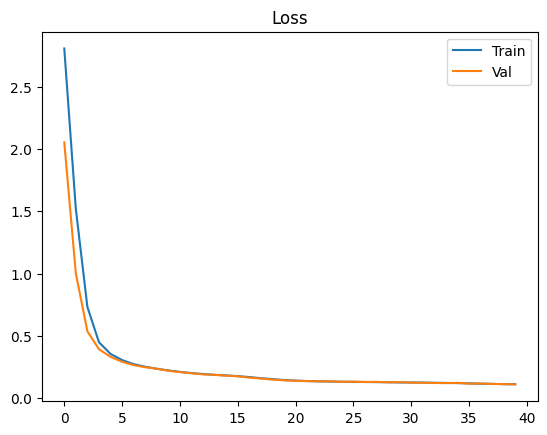

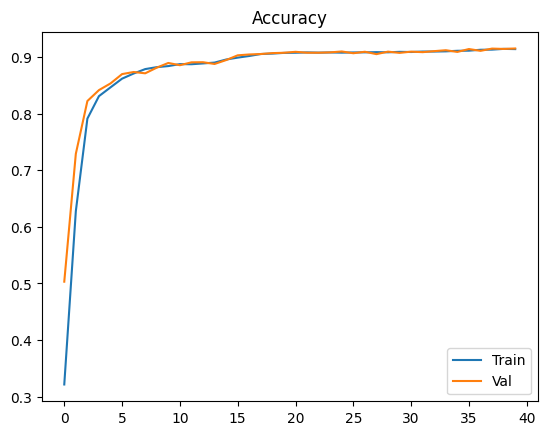

In [10]:

plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Train","Val"])
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Train","Val"])
plt.title("Accuracy")
plt.show()


## Correct Autoregressive Inference

In [11]:

def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-z\s]", "", t)
    return t.strip()

def generate_feedback(x_enc):
    seq = [word2idx["<start>"]]
    for _ in range(max_len):
        padded = pad_sequences([seq], maxlen=max_len-1, padding="post")
        preds = model.predict([x_enc, padded], verbose=0)
        next_id = np.argmax(preds[0, len(seq)-1])
        if next_id == word2idx["<end>"]:
            break
        seq.append(next_id)

    return " ".join(
        idx2word[i] for i in seq
        if i not in [word2idx["<start>"], word2idx["<pad>"]]
    )


## Evaluation (Word Overlap + Cosine Similarity)

In [12]:

test_df = pd.read_csv("/content/drive/MyDrive/u222nique_feedback_paragraphs.csv").head(10)

real_paragraphs, predicted_paragraphs, overlaps = [], [], []

for _, row in test_df.iterrows():
    X_num = scaler.transform(pd.DataFrame([row[numeric_cols]], columns=numeric_cols))
    X_shot = shot_encoder.transform(pd.DataFrame([row[["shot_type"]]], columns=["shot_type"]))
    X_enc = np.concatenate([X_num, X_shot], axis=1).reshape(1, -1, 1)

    pred = generate_feedback(X_enc)
    real = row["feedback_paragraph"]

    rc, pc = clean_text(real), clean_text(pred)

    real_paragraphs.append(rc)
    predicted_paragraphs.append(pc)

    overlap = len(set(rc.split()) & set(pc.split())) / len(set(rc.split())) * 100
    overlaps.append(overlap)

print("OVERALL WORD OVERLAP:", np.mean(overlaps))


OVERALL WORD OVERLAP: 72.43506493506494


In [13]:

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(real_paragraphs + predicted_paragraphs)

real_vecs = tfidf[:len(real_paragraphs)]
pred_vecs = tfidf[len(real_paragraphs):]

cos_sim = cosine_similarity(real_vecs, pred_vecs).diagonal().mean()
print("SENTENCE COSINE SIMILARITY:", cos_sim*100)


SENTENCE COSINE SIMILARITY: 69.69352262677418


## Length Comparison Plots

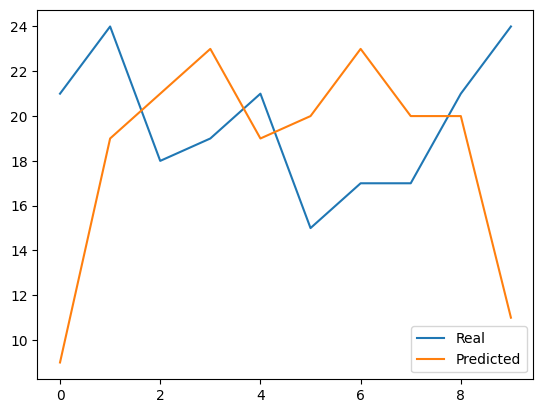

In [14]:

real_lengths = [len(p.split()) for p in real_paragraphs]
pred_lengths = [len(p.split()) for p in predicted_paragraphs]

plt.figure()
plt.plot(real_lengths, label="Real")
plt.plot(pred_lengths, label="Predicted")
plt.legend()
plt.show()



================ REAL vs PREDICTED =================

Row 1
REAL     : good sweep shot bat angle hit quality provide controlled execution weak stance bend reduce shot effectiveness improving confidence will add consistency
PREDICTED: sweep shot sweep shot stance bend reduce shot effectiveness
WORD OVERLAP: 30.00%
------------------------------------------------------------
Row 2
REAL     : good cover shot face stability shot accuracy provide controlled execution weak bat angle reduce shot effectiveness improving front foot stance score will add consistency
PREDICTED: cover shot bat angle face stability shot accuracy reduce shot effectiveness improving front foot stance score will add consistency
WORD OVERLAP: 77.27%
------------------------------------------------------------
Row 3
REAL     : excellent sweep shot bat angle hit quality stance bend provide controlled execution improving face stability will add consistency
PREDICTED: sweep shot sweep shot bat angle hit quality stance ben

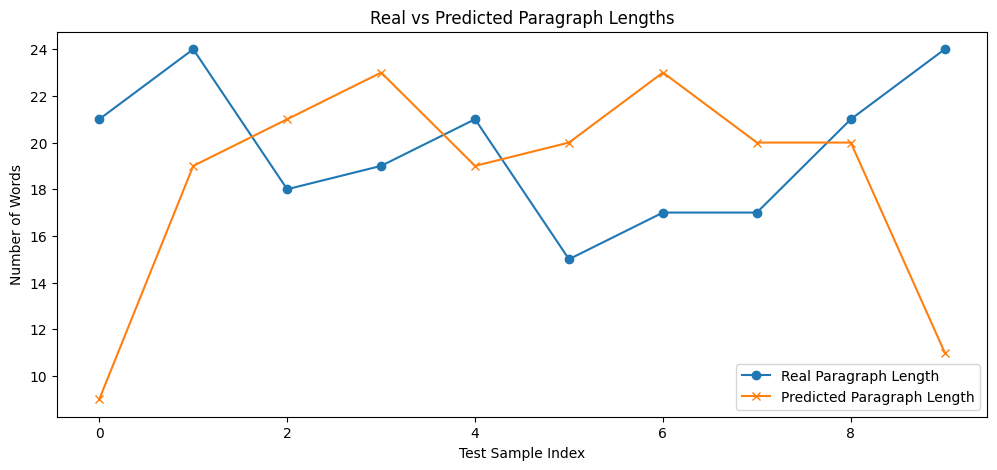

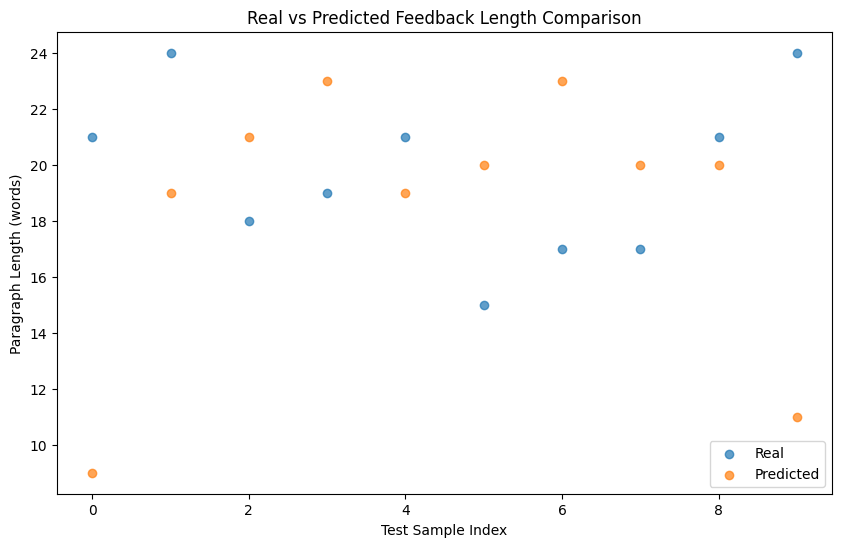

In [19]:
# ==========================
# CORRECTED INFERENCE CELL
# ==========================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# ------------------------------
# 1️⃣ Load model & preprocessing
# ------------------------------
model = tf.keras.models.load_model("/content/drive/MyDrive/cric_feedback_model_3.keras")

word2idx = pickle.load(open("/content/drive/MyDrive/word2idx.pkl", "rb"))
idx2word = pickle.load(open("/content/drive/MyDrive/idx2word.pkl", "rb"))

scaler = pickle.load(open("/content/drive/MyDrive/scaler.pkl", "rb"))
shot_encoder = pickle.load(open("/content/drive/MyDrive/shot_encoder.pkl", "rb"))

# ------------------------------
# 2️⃣ Load test data (first 10 rows)
# ------------------------------
test_df = pd.read_csv("/content/drive/MyDrive/u222nique_feedback_paragraphs.csv").head(10)

numeric_cols = [
    "confidence", "bat_angle", "hit_quality",
    "face_stability", "stance_bend",
    "front_foot_stance_score", "shot_accuracy"
]

max_len = model.input[1].shape[1]  # decoder input length

# ------------------------------
# 3️⃣ Utilities
# ------------------------------
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-z\s]", "", t)
    return t.strip()

def generate_feedback(x_enc, max_len=max_len):
    """
    Autoregressive seq2seq inference: predicts one word at a time
    """
    seq = [word2idx["<start>"]]
    predicted_words = []

    for _ in range(max_len):
        # Pad sequence to decoder input length
        padded = pad_sequences([seq], maxlen=max_len, padding="post")
        preds = model.predict([x_enc, padded], verbose=0)

        # Predict next word at current position
        next_id = np.argmax(preds[0, len(seq)-1])

        if next_id == word2idx["<end>"]:
            break

        seq.append(next_id)
        predicted_words.append(idx2word[next_id])

    return " ".join(predicted_words)

# ------------------------------
# 4️⃣ Generate predictions & word-overlap
# ------------------------------
real_paragraphs, predicted_paragraphs, overlaps = [], [], []

print("\n================ REAL vs PREDICTED =================\n")

for i, row in test_df.iterrows():
    # Prepare encoder input
    X_num = scaler.transform(pd.DataFrame([row[numeric_cols]], columns=numeric_cols))
    X_shot = shot_encoder.transform(pd.DataFrame([row[["shot_type"]]], columns=["shot_type"]))
    X_enc = np.concatenate([X_num, X_shot], axis=1)

    # Generate feedback
    pred = generate_feedback(X_enc)
    real = row["feedback_paragraph"]

    rc = clean_text(real)
    pc = clean_text(pred)

    real_paragraphs.append(rc)
    predicted_paragraphs.append(pc)

    # Word-overlap
    overlap = len(set(rc.split()) & set(pc.split())) / len(set(rc.split())) * 100
    overlaps.append(overlap)

    # Print per row
    print(f"Row {i+1}")
    print("REAL     :", rc)
    print("PREDICTED:", pc)
    print(f"WORD OVERLAP: {overlap:.2f}%")
    print("-"*60)

# ------------------------------
# 5️⃣ Overall metrics
# ------------------------------
overall_overlap = np.mean(overlaps)
print(f"\nOVERALL WORD OVERLAP (10 rows): {overall_overlap:.2f}%")

# Sentence-level cosine similarity
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(real_paragraphs + predicted_paragraphs)

real_vecs = tfidf[:len(real_paragraphs)]
pred_vecs = tfidf[len(real_paragraphs):]

sentence_similarity = cosine_similarity(real_vecs, pred_vecs).diagonal().mean()
print(f"SENTENCE-LEVEL COSINE SIMILARITY: {sentence_similarity*100:.2f}%")

# ------------------------------
# 6️⃣ Optional: Paragraph length comparison
# ------------------------------
real_lengths = [len(p.split()) for p in real_paragraphs]
pred_lengths = [len(p.split()) for p in predicted_paragraphs]

plt.figure(figsize=(12,5))
plt.plot(real_lengths, label="Real Paragraph Length", marker='o')
plt.plot(pred_lengths, label="Predicted Paragraph Length", marker='x')
plt.xlabel("Test Sample Index")
plt.ylabel("Number of Words")
plt.title("Real vs Predicted Paragraph Lengths")
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(range(len(real_lengths)), real_lengths, label="Real", alpha=0.7)
plt.scatter(range(len(pred_lengths)), pred_lengths, label="Predicted", alpha=0.7)
plt.xlabel("Test Sample Index")
plt.ylabel("Paragraph Length (words)")
plt.title("Real vs Predicted Feedback Length Comparison")
plt.legend()
plt.show()


Vocabulary size: 41


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,664 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 25, 128)   │      5,248 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 25, 128), │    131,584 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ dense_2[0][0],    │
│                     │ (None, 128)]      │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 25, 41)    │      5,289 │ lstm_2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 176,809 (690.66 KB)

 Trainable params: 176,809 (690.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5636 - loss: 1.6663 - val_accuracy: 0.9068 - val_loss: 0.1666
Epoch 2/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9092 - loss: 0.1526 - val_accuracy: 0.9200 - val_loss: 0.1189
Epoch 3/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9241 - loss: 0.1061 - val_accuracy: 0.9294 - val_loss: 0.0863
Epoch 4/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9315 - loss: 0.0815 - val_accuracy: 0.9338 - val_loss: 0.0703
Epoch 5/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9357 - loss: 0.0665 - val_accuracy: 0.9333 - val_loss: 0.0656
Epoch 6/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9393 - loss: 0.0566 - val_accuracy: 0.9434 - val_loss: 0.0436
Epoch 7/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9440 - loss: 0.0449 - val_accuracy: 0.9435 - val_loss: 0.0438
Epoch 8/40
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9457 - loss: 0.0400 - val_accuracy: 0

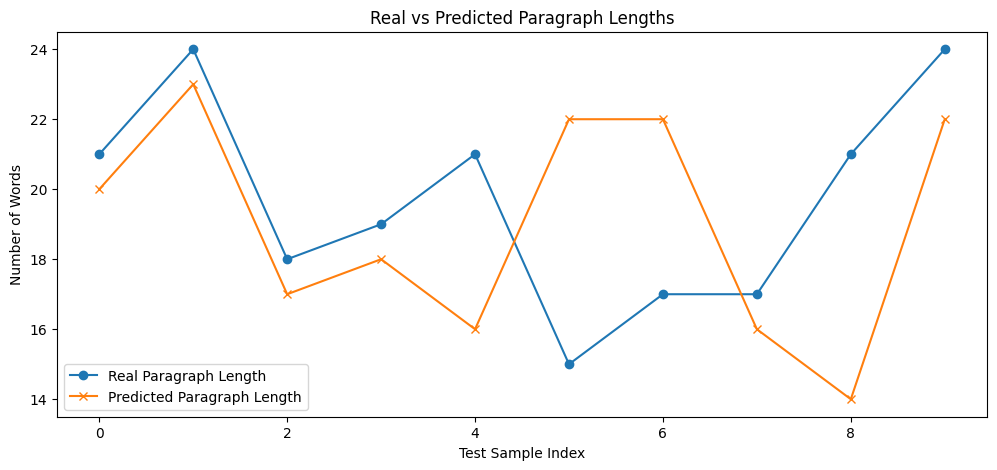

In [20]:
# =========================
# Cricket Shot Feedback Seq2Seq
# Manual Tokenization + Autoregressive Inference
# =========================

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import re

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# =========================
# 1️⃣ Data Load and Encoder Input
# =========================
df = pd.read_csv("/content/drive/MyDrive/cricket_shot_feedback_dataset_FINAL.csv")
numeric_cols = ["confidence", "bat_angle", "hit_quality", "face_stability",
                "stance_bend", "front_foot_stance_score", "shot_accuracy"]

# Scale numeric inputs
scaler = MinMaxScaler()
X_num = scaler.fit_transform(df[numeric_cols])

# Encode shot_type
shot_encoder = OneHotEncoder(sparse_output=False)
X_shot = shot_encoder.fit_transform(df[["shot_type"]])

# Combine encoder input
X_encoder = np.concatenate([X_num, X_shot], axis=1)

# =========================
# 2️⃣ Manual Tokenization
# =========================
texts = []
for sentence in df["feedback_paragraph"]:
    sentence = sentence.lower()
    sentence = "<start> " + sentence + " <end>"
    texts.append(sentence)

# Split words
tokenized_texts = [s.split() for s in texts]

# =========================
# 3️⃣ Build Vocabulary
# =========================
vocab = []
for sentence in tokenized_texts:
    for word in sentence:
        if word not in vocab:
            vocab.append(word)

vocab.append("<pad>")  # ensure padding

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

# =========================
# 4️⃣ Convert words to sequences and pad
# =========================
sequences = [[word2idx[w] for w in s] for s in tokenized_texts]
max_len = max(len(s) for s in sequences)
padded_sequences = [s + [word2idx["<pad>"]] * (max_len - len(s)) for s in sequences]
padded_sequences = np.array(padded_sequences)

# Decoder input & target
decoder_input = padded_sequences[:, :-1]
decoder_target = padded_sequences[:, 1:]
decoder_target = to_categorical(decoder_target, num_classes=vocab_size)

# =========================
# 5️⃣ Encoder-Decoder Model
# =========================
embedding_dim = 128
lstm_units = 128

encoder_input_layer = Input(shape=(X_encoder.shape[1],))
x = Dense(128, activation='relu')(encoder_input_layer)
state_h = Dense(lstm_units, activation='tanh')(x)
state_c = Dense(lstm_units, activation='tanh')(x)

decoder_input_layer = Input(shape=(max_len-1,))
embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)(decoder_input_layer)
decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)
decoder_output, _, _ = decoder_lstm(embedding, initial_state=[state_h, state_c])
output_layer = Dense(vocab_size, activation='softmax')(decoder_output)

model = Model([encoder_input_layer, decoder_input_layer], output_layer)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# =========================
# 6️⃣ Train Model
# =========================
history = model.fit([X_encoder, decoder_input], decoder_target, epochs=40, batch_size=8, validation_split=0.1)

# Save model & preprocessors
model.save("/content/drive/MyDrive/cric_feedback_model_manual.keras")
pickle.dump(word2idx, open("/content/drive/MyDrive/word2idx.pkl", "wb"))
pickle.dump(idx2word, open("/content/drive/MyDrive/idx2word.pkl", "wb"))
pickle.dump(scaler, open("/content/drive/MyDrive/scaler.pkl", "wb"))
pickle.dump(shot_encoder, open("/content/drive/MyDrive/shot_encoder.pkl", "wb"))

# =========================
# 7️⃣ Autoregressive Inference
# =========================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

def generate_feedback(x_enc, max_len=max_len):
    seq = [word2idx['<start>']]
    words = []
    for _ in range(max_len):
        padded = pad_sequences([seq], maxlen=max_len-1, padding='post')
        preds = model.predict([x_enc, padded], verbose=0)
        next_id = np.argmax(preds[0, len(seq)-1])
        if next_id == word2idx['<end>']:
            break
        seq.append(next_id)
        words.append(idx2word[next_id])
    return ' '.join(words)

# =========================
# 8️⃣ Evaluation: first 10 rows
# =========================
test_df = pd.read_csv("/content/drive/MyDrive/u222nique_feedback_paragraphs.csv").head(10)
real_paragraphs, predicted_paragraphs, overlaps = [], [], []

for _, row in test_df.iterrows():
    X_num_scaled = scaler.transform(pd.DataFrame([row[numeric_cols]], columns=numeric_cols))
    X_shot_encoded = shot_encoder.transform(pd.DataFrame([row[['shot_type']]], columns=['shot_type']))
    X_enc = np.concatenate([X_num_scaled, X_shot_encoded], axis=1)

    pred = generate_feedback(X_enc)
    real = row['feedback_paragraph']

    rc, pc = clean_text(real), clean_text(pred)
    real_paragraphs.append(rc)
    predicted_paragraphs.append(pc)

    overlap = len(set(rc.split()) & set(pc.split())) / len(set(rc.split())) * 100
    overlaps.append(overlap)

# Print real vs predicted
print("================ REAL vs PREDICTED =================")
for i in range(len(real_paragraphs)):
    print(f"Row {i+1}")
    print("REAL     :", real_paragraphs[i])
    print("PREDICTED:", predicted_paragraphs[i])
    print("WORD OVERLAP:", round(overlaps[i],2), "%")
    print("-"*60)

print("OVERALL WORD OVERLAP:", round(np.mean(overlaps),2))

# Sentence-level cosine similarity
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(real_paragraphs + predicted_paragraphs)
real_vecs = tfidf[:len(real_paragraphs)]
pred_vecs = tfidf[len(real_paragraphs):]
sentence_similarity = cosine_similarity(real_vecs, pred_vecs).diagonal().mean()
print("SENTENCE-LEVEL COSINE SIMILARITY:", round(sentence_similarity*100,2), "%")

# Plot paragraph lengths
real_lengths = [len(p.split()) for p in real_paragraphs]
pred_lengths = [len(p.split()) for p in predicted_paragraphs]

plt.figure(figsize=(12,5))
plt.plot(real_lengths, label='Real Paragraph Length', marker='o')
plt.plot(pred_lengths, label='Predicted Paragraph Length', marker='x')
plt.xlabel('Test Sample Index')
plt.ylabel('Number of Words')
plt.title('Real vs Predicted Paragraph Lengths')
plt.legend()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
import pickle

# ------------------------------
# 1️⃣ Load model & preprocessing
# ------------------------------
model = tf.keras.models.load_model("/content/drive/MyDrive/cric_feedback_model.keras")
word2idx = pickle.load(open("/content/drive/MyDrive/word2idx.pkl", "rb"))
idx2word = pickle.load(open("/content/drive/MyDrive/idx2word.pkl", "rb"))
scaler = pickle.load(open("/content/drive/MyDrive/scaler.pkl", "rb"))
shot_encoder = pickle.load(open("/content/drive/MyDrive/shot_encoder.pkl", "rb"))

# ------------------------------
# 2️⃣ Load test data
# ------------------------------
test_df = pd.read_csv("/content/drive/MyDrive/u222nique_feedback_paragraphs.csv").head(10)
numeric_cols = ["confidence", "bat_angle", "hit_quality", "face_stability",
                "stance_bend", "front_foot_stance_score", "shot_accuracy"]

max_len = model.input[1].shape[1]

# ------------------------------
# 3️⃣ Utilities
# ------------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = text.replace("start", "").replace("end", "")
    return text.strip()

def generate_feedback(x_enc):
    seq = [word2idx["<start>"]]

    for _ in range(max_len):
        padded = pad_sequences([seq], maxlen=max_len, padding="post")
        preds = model.predict([x_enc, padded], verbose=0)
        next_id = np.argmax(preds[0, len(seq)-1])
        if next_id == word2idx["<end>"]:
            break
        seq.append(next_id)

    return " ".join(idx2word[i] for i in seq if i not in [word2idx["<start>"], word2idx["<pad>"]])

# ------------------------------
# 4️⃣ Generate & Print first 10 rows
# ------------------------------
real_paragraphs, predicted_paragraphs, overlaps = [], [], []

print("\n========= REAL vs PREDICTED =========\n")

for i, row in test_df.iterrows():
    X_num_scaled = scaler.transform(pd.DataFrame([row[numeric_cols]], columns=numeric_cols))
    X_shot_encoded = shot_encoder.transform(pd.DataFrame([row[["shot_type"]]], columns=["shot_type"]))
    X_enc = np.concatenate([X_num_scaled, X_shot_encoded], axis=1)

    predicted = generate_feedback(X_enc)
    real = row["feedback_paragraph"]

    predicted_clean = clean_text(predicted)
    real_clean = clean_text(real)

    real_paragraphs.append(real_clean)
    predicted_paragraphs.append(predicted_clean)

    # Word-overlap per sample
    real_set = set(real_clean.split())
    pred_set = set(predicted_clean.split())
    overlap = len(real_set & pred_set) / len(real_set) * 100
    overlaps.append(overlap)

    print(f"Row {i+1}")
    print("REAL     :", real_clean)
    print("PREDICTED:", predicted_clean)
    print(f"WORD OVERLAP: {overlap:.2f}%")
    print("-"*60)

overall_overlap = np.mean(overlaps)
print(f"\nOVERALL WORD-OVERLAP (10 rows): {overall_overlap:.2f}%")


KeyboardInterrupt: 